In [1]:
# ============================================================
# PROYECTO: Análisis de Riesgo Crediticio - Banco Checoslovaco
# SCRIPT: 01_analisis_python.ipynb
# AUTOR: Mac Alvarado
# FECHA: 30/06/2026
# DESCRIPCIÓN: Análisis exploratorio y visualizaciones en Python
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

# Configurar visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(" Librerías importadas correctamente")

# ============================================================
# CONEXIÓN A SQL SERVER
# ============================================================

def conectar_sql():
    """Conecta a la base de datos BancoChecoslovaco en SQL Server"""
    try:
        conn = pyodbc.connect(
            'DRIVER={ODBC Driver 17 for SQL Server};'
            'SERVER=.;'
            'DATABASE=BancoChecoslovaco;'
            'Trusted_Connection=yes;'
        )
        print("✅ Conexión exitosa a SQL Server")
        return conn
    except Exception as e:
        print(f"❌ Error de conexión: {e}")
        return None

# Probar conexión
conn = conectar_sql()

 Librerías importadas correctamente
✅ Conexión exitosa a SQL Server


In [2]:
# ============================================================
# CARGAR DATOS DESDE SQL SERVER
# ============================================================

def cargar_datos(conn):
    """Carga las tablas principales desde SQL Server"""
    
    # 1. Clientes
    query_client = "SELECT * FROM client"
    df_client = pd.read_sql(query_client, conn)
    print(f"✅ Clientes: {len(df_client):,} registros")
    
    # 2. Cuentas
    query_account = "SELECT * FROM [account]"
    df_account = pd.read_sql(query_account, conn)
    print(f"✅ Cuentas: {len(df_account):,} registros")
    
    # 3. Préstamos (con distrito)
    query_loan = """
        SELECT 
            l.loan_id,
            l.account_id,
            l.date_issued,
            l.amount,
            l.duration,
            l.payments,
            l.status,
            d.district_name,
            d.region
        FROM loan l
        JOIN account a ON l.account_id = a.account_id
        JOIN district d ON a.district_id = d.district_id
    """
    df_loan = pd.read_sql(query_loan, conn)
    print(f"✅ Préstamos: {len(df_loan):,} registros")
    
    # 4. Transacciones (solo las primeras 100,000 para no sobrecargar)
    query_trans = """
        SELECT TOP 100000
            trans_id,
            account_id,
            trans_date,
            type,
            operation,
            amount,
            balance
        FROM [transaction]
    """
    df_trans = pd.read_sql(query_trans, conn)
    print(f"✅ Transacciones: {len(df_trans):,} registros (muestra)")
    
    return df_client, df_account, df_loan, df_trans

# Cargar datos
df_client, df_account, df_loan, df_trans = cargar_datos(conn)

# Cerrar conexión
conn.close()
print("🔒 Conexión cerrada")

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_20128\272605069.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_client = pd.read_sql(query_client, conn)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_20128\272605069.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_account = pd.read_sql(query_account, conn)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_20128\272605069.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_loan = pd.read_sql(query_loan, conn)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_20128\27

✅ Clientes: 5,369 registros
✅ Cuentas: 4,500 registros
✅ Préstamos: 674 registros
✅ Transacciones: 100,000 registros (muestra)
🔒 Conexión cerrada


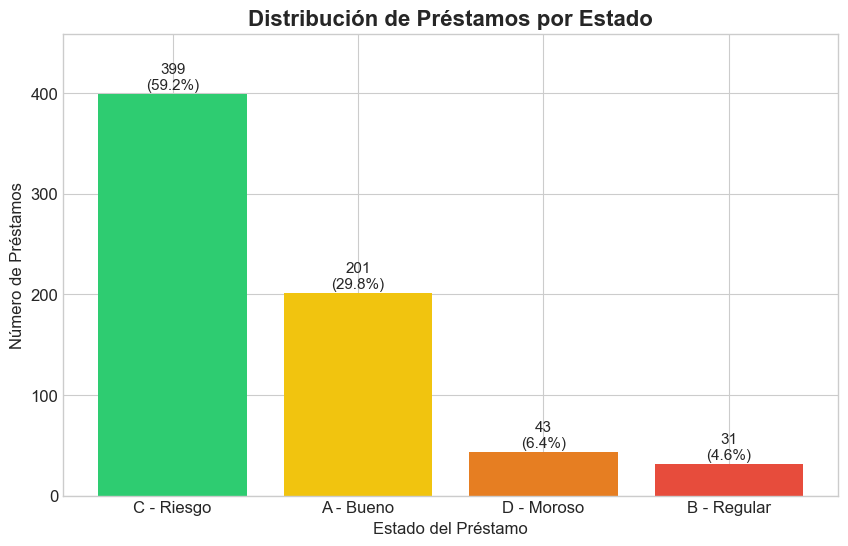

✅ Gráfico guardado: py_distribucion_estados.png


In [3]:
# ============================================================
# GRÁFICO 1: Distribución de préstamos por estado
# ============================================================

# Preparar datos
estados = df_loan['status'].value_counts()
estados_labels = {
    '"A"': 'A - Bueno',
    '"B"': 'B - Regular',
    '"C"': 'C - Riesgo',
    '"D"': 'D - Moroso'
}
estados_nombres = [estados_labels.get(x, x) for x in estados.index]

# Crear gráfico
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(estados_nombres, estados.values, color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])

# Añadir etiquetas
for bar, val in zip(bars, estados.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            f'{val}\n({val/len(df_loan)*100:.1f}%)', 
            ha='center', va='bottom', fontsize=11)

ax.set_title('Distribución de Préstamos por Estado', fontsize=16, weight='bold')
ax.set_xlabel('Estado del Préstamo')
ax.set_ylabel('Número de Préstamos')
ax.set_ylim(0, max(estados.values) * 1.15)

# Guardar imagen
plt.savefig('../images/py_distribucion_estados.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado: py_distribucion_estados.png")

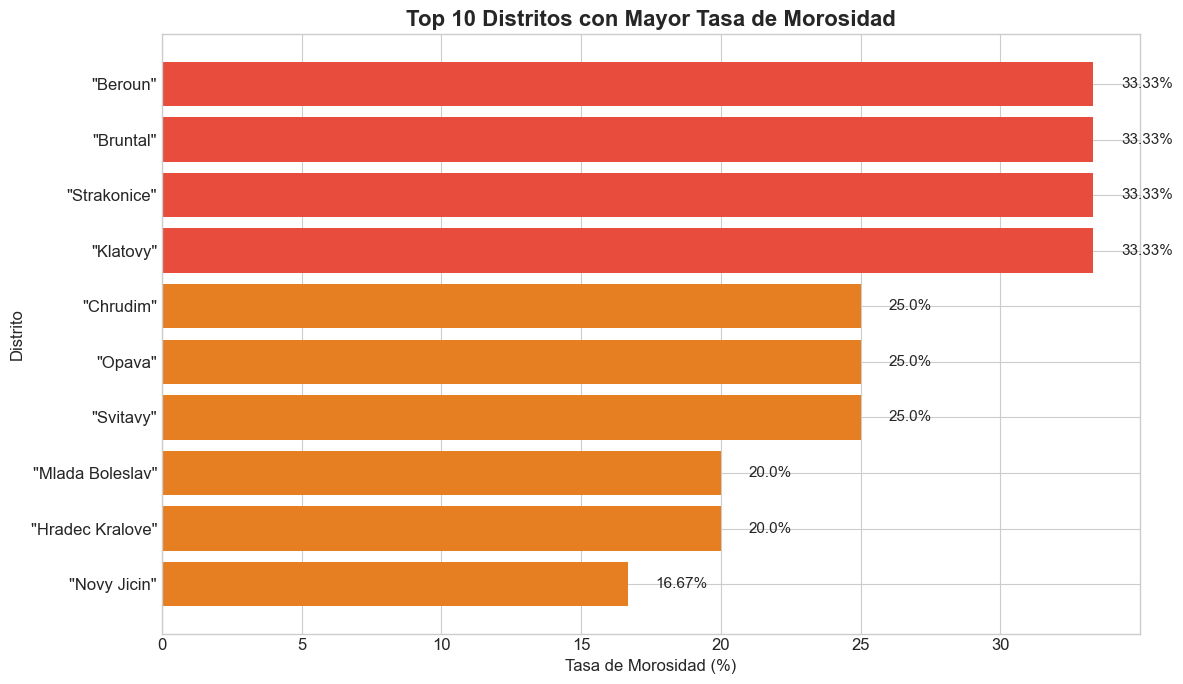

✅ Gráfico guardado: py_top_morosidad.png


In [4]:
# ============================================================
# GRÁFICO 2: Top 10 distritos con mayor morosidad
# ============================================================

# Calcular morosidad por distrito
morosidad = df_loan.groupby('district_name').agg(
    total=('loan_id', 'count'),
    morosos=('status', lambda x: (x == '"D"').sum())
).reset_index()

morosidad['tasa'] = (morosidad['morosos'] / morosidad['total'] * 100).round(2)
morosidad = morosidad[morosidad['total'] >= 3].sort_values('tasa', ascending=False).head(10)

# Crear gráfico
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if x > 30 else '#e67e22' if x > 15 else '#f1c40f' for x in morosidad['tasa']]
bars = ax.barh(morosidad['district_name'], morosidad['tasa'], color=colors)

ax.set_title('Top 10 Distritos con Mayor Tasa de Morosidad', fontsize=16, weight='bold')
ax.set_xlabel('Tasa de Morosidad (%)')
ax.set_ylabel('Distrito')

# Añadir etiquetas
for bar, val in zip(bars, morosidad['tasa']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{val}%', va='center', fontsize=11)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../images/py_top_morosidad.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado: py_top_morosidad.png")

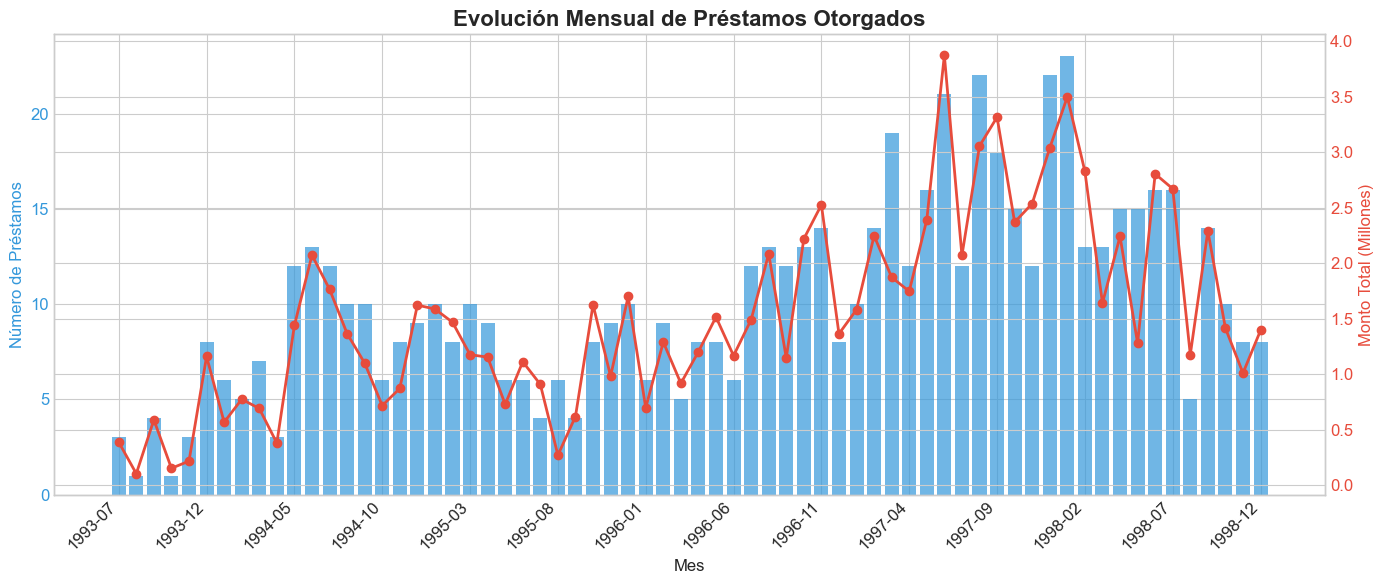

✅ Gráfico guardado: py_evolucion_mensual.png


In [7]:
# ============================================================
# GRÁFICO 3: Evolución mensual de préstamos (CORREGIDO)
# ============================================================

# Preparar datos temporales
df_loan['date_issued'] = pd.to_datetime(df_loan['date_issued'])
df_loan['mes'] = df_loan['date_issued'].dt.to_period('M')
evolucion = df_loan.groupby('mes').agg(
    total=('loan_id', 'count'),
    monto=('amount', 'sum')
).reset_index()
evolucion['mes_str'] = evolucion['mes'].astype(str)

# Crear gráfico - VERSIÓN CORREGIDA
fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras: cantidad de préstamos
ax1.bar(evolucion['mes_str'], evolucion['total'], color='#3498db', alpha=0.7, label='N° Préstamos')
ax1.set_xlabel('Mes', fontsize=12)
ax1.set_ylabel('Número de Préstamos', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

# Reducir la cantidad de etiquetas en el eje X (mostrar cada 6 meses)
step = max(1, len(evolucion) // 12)
ax1.set_xticks(evolucion['mes_str'][::step])
ax1.set_xticklabels(evolucion['mes_str'][::step], rotation=45, ha='right')

# Línea: monto total
ax2 = ax1.twinx()
ax2.plot(evolucion['mes_str'], evolucion['monto'] / 1000000, color='#e74c3c', marker='o', linewidth=2, label='Monto (Millones)')
ax2.set_ylabel('Monto Total (Millones)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Título y leyenda
plt.title('Evolución Mensual de Préstamos Otorgados', fontsize=16, weight='bold')
fig.tight_layout()

# Guardar imagen
plt.savefig('../images/py_evolucion_mensual.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado: py_evolucion_mensual.png")

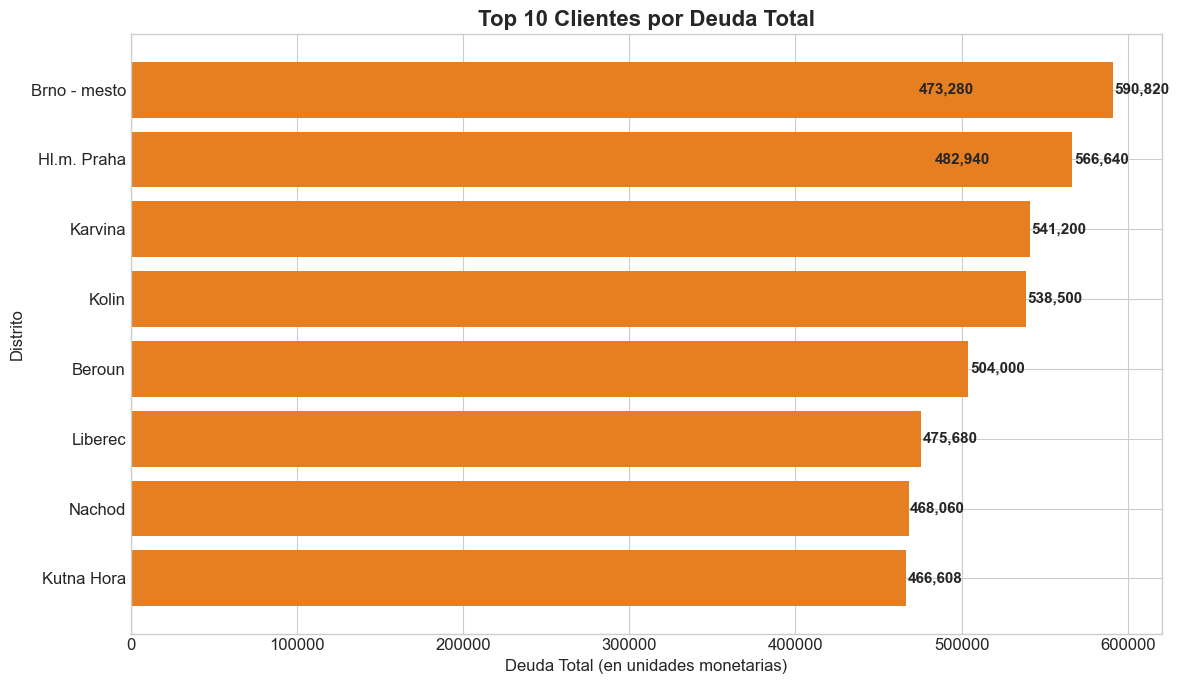

✅ Gráfico guardado: py_top_deuda.png


In [9]:
# ============================================================
# GRÁFICO 4: Top 10 clientes por deuda total (CORREGIDO)
# ============================================================

# Calcular deuda por cliente
deuda_clientes = df_loan.groupby('account_id').agg(
    deuda_total=('amount', 'sum'),
    total_prestamos=('loan_id', 'count')
).reset_index().sort_values('deuda_total', ascending=False).head(10)

# Unir con distrito
deuda_clientes = deuda_clientes.merge(
    df_loan[['account_id', 'district_name']].drop_duplicates(), 
    on='account_id'
)

# Crear gráfico - VERSIÓN CORREGIDA (sin etiquetas duplicadas)
fig, ax = plt.subplots(figsize=(12, 7))

# Quitar comillas dobles de los nombres
deuda_clientes['district_name_clean'] = deuda_clientes['district_name'].str.replace('"', '')

bars = ax.barh(deuda_clientes['district_name_clean'], deuda_clientes['deuda_total'], color='#e67e22')

ax.set_title('Top 10 Clientes por Deuda Total', fontsize=16, weight='bold')
ax.set_xlabel('Deuda Total (en unidades monetarias)', fontsize=12)
ax.set_ylabel('Distrito', fontsize=12)

# Añadir etiquetas (una sola vez)
for i, (bar, val) in enumerate(zip(bars, deuda_clientes['deuda_total'])):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2, 
            f'{val:,.0f}', va='center', fontsize=11, weight='bold')

plt.gca().invert_yaxis()
plt.tight_layout()

# Guardar imagen
plt.savefig('../images/py_top_deuda.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado: py_top_deuda.png")